In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, create_folder, read_experiment_json, compute_means_for_folder_tests
import os

In [4]:
results_folder = "../tests_L_min/3D/"
create_folder(results_folder)

Folder created: ../tests_L_min/3D/


## COMPUTE MEANS FOR FOLDERS

In [23]:
DIM = 3
N_COLORS = 2
base = f"../Data_tests/bond_percolation/num_colors_{N_COLORS}/dim_{DIM}/"
L_lst = []

for entry in os.scandir(base):
    if entry.is_dir():
        L_lst.append(entry.path[-3:])
        
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS
p0 = [1.0]
for L in L_lst:
    compute_means_for_folder_tests(type_perc='bond', num_colors=N_COLORS, dim=DIM, L=L, NT=NT, k=K, rho=RHO, p0_list=p0)

[ok] p0=1.00: 20 arquivos | seeds=20 | pc_SOP=0.301733±0.000188
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_215/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 20 arquivos | seeds=20 | pc_SOP=0.294146±0.000105
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_225/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 11 arquivos | seeds=11 | pc_SOP=0.317221±0.000241
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_200/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 10 arquivos | seeds=10 | pc_SOP=0.285374±0.000252
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_240/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 20 arquivos | seeds=20 | pc_SOP=0.297510±0.000160
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_220/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.

## SINGLE SAMPLE

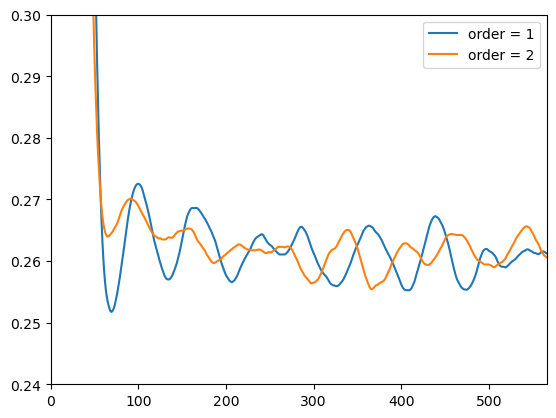

In [29]:
DIM = 3
N_COLORS = 2
L = 220
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS
p0 = 1.0
folder_base = f"../Data_tests/bond_percolation/num_colors_{N_COLORS}/dim_{DIM}/L_{L}/NT_constant/NT_{NT}/k_{K:.1e}/rho_{RHO:.4e}/data/"
fn = select_random_json(folder_base, p0=p0)
ts = read_experiment_json(fn)
for i in range(1,N_COLORS+1):
    t = np.asarray(ts['results'][f'order_percolation {i}']['data']['time'])
    pt = np.asarray(ts['results'][f'order_percolation {i}']['data']['pt'])
    plt.plot(t, pt, label=f'order = {i}')
plt.ylim([0.24, 0.3])
plt.xlim([0, max(t)])
plt.legend()
plt.show()


## MULTI SAMPLE

return data with keys dict_keys(['time', 'pt_mean', 'pt_sem', 'n_seeds_pt', 'nt_mean', 'nt_sem', 'n_seeds_nt', 'M_size_mean', 'M_size_sem', 'n_seeds_M_size'])


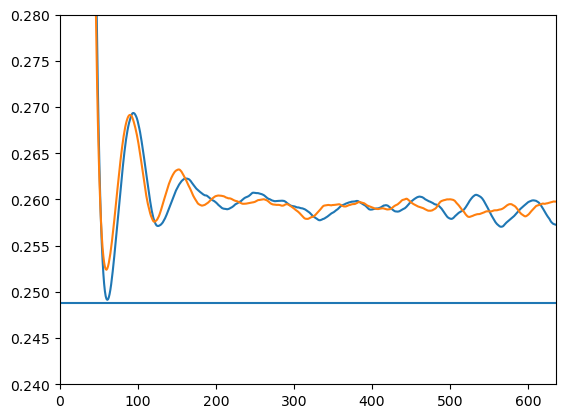

In [75]:
import json

DIM = 3
N_COLORS = 2
L = 235
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS
p0 = 1.0

def read_mean_json(N_COLORS:int, DIM:int, L:int, NT:int, K:float, RHO:float):
    filename = (
        f"../Data_tests/bond_percolation/num_colors_{N_COLORS}/dim_{DIM}/"
        f"L_{L}/NT_constant/NT_{NT}/k_{K:.1e}/rho_{RHO:.4e}/properties_mean_bundle.json"
    )

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    keys = data['p0_groups'][0]['orders'][0]['data'].keys()
    print(f'return data with keys {keys}')
    
    return data['p0_groups'][0]['orders']

data = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
pc = 0.2488125
for i in range(2):
    data_filter = data[i]['data']
    t, pt = data_filter['time'], data_filter['pt_mean']
    plt.plot(t, pt)

plt.axhline(y=pc)
plt.xlim(0,max(t))
plt.ylim(0.24, 0.28)
plt.show()
